# Notebook 04 — Substructure Searching: Automated Functional Group Recognition

In the wet lab, you develop an intuition for reading structures: you glance at a molecule and instantly
spot the carboxylic acid, the ester linkage, the aromatic amine. Substructure searching is the
computational equivalent — it lets you encode that chemical intuition as a query and run it against
thousands (or millions) of molecules programmatically.

**SMARTS** (SMiles ARbitrary Target Specification) is the query language that powers this. Think of it
as SMILES on steroids: while SMILES describes *specific* molecules, SMARTS describes *patterns* of atoms
and bonds. It's like having an automated TLC scanner for functional groups — except instead of Rf values,
you're matching atom environments.

**What we'll cover:**
1. **SMARTS deep dive** — Atomic primitives, bond primitives, and recursive SMARTS
2. **Substructure matching** — `HasSubstructMatch`, `GetSubstructMatch`, `GetSubstructMatches`
3. **Practical SMARTS library** — Building a functional group scanner from scratch
4. **Maximum Common Substructure (MCS)** — Finding shared scaffolds across molecules

By the end, you'll be able to build an automated functional group classifier that does in milliseconds
what takes a chemist minutes of manual inspection.

In [2]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, rdFMCS
import pandas as pd

---

## 1. SMARTS Deep Dive

### Chemistry refresher: From SMILES to SMARTS

You already know SMILES — it's a line notation for *specific* molecules. SMARTS extends SMILES with
**query features** that let you describe *classes* of atoms and bonds rather than exact ones.

| Concept | SMILES | SMARTS |
|---------|--------|--------|
| Carbon atom | `C` (aliphatic) or `c` (aromatic) | `[#6]` (any carbon, regardless of aromaticity) |
| Oxygen | `O` | `[OX2H1]` (oxygen with 2 connections and 1 hydrogen) |
| Any bond | implicit single | `~` (any bond type) |

**Why does this matter?** When you're classifying reactivity in the lab, you don't care if a carbon is
atom index 3 or 7 — you care about its *environment*: Is it sp3? Is it in a ring? How many hydrogens
does it bear? SMARTS lets you express exactly these structural queries.

### 1.1 Atomic Primitives

These are the building blocks of SMARTS patterns. Each primitive constrains what kind of atom can match:

| Primitive | Meaning | Wet-lab analogy |
|-----------|---------|-----------------|
| `[#6]` | Atomic number 6 (any carbon) | "Find me all carbons" |
| `[C]` | Aliphatic carbon | sp3 carbons (saturated) |
| `[c]` | Aromatic carbon | Carbons in aromatic rings (think benzene, pyridine) |
| `[C,N]` | Carbon OR nitrogen | Logical OR — matches either |
| `[!#1]` | NOT hydrogen | Heavy atoms only |
| `[R]` | In any ring | Ring membership — like asking "is this in a cyclic system?" |
| `[R2]` | In exactly 2 rings | Fused ring systems (e.g., naphthalene junction atoms) |
| `[r6]` | In a 6-membered ring | Ring size — benzene, cyclohexane, pyridine |
| `[D3]` | Degree 3 (3 explicit connections) | Branching point — like a tertiary carbon |
| `[X3]` | Total connections = 3 (incl. implicit H) | Total connectivity including implicit hydrogens |
| `[v4]` | Valence 4 | Total bond order = 4 (e.g., carbon with 4 single bonds) |
| `[+1]` | Formal charge +1 | Quaternary ammonium, protonated amine |
| `[H1]` | Exactly 1 hydrogen | Useful for distinguishing primary/secondary/tertiary |

In [3]:
# --- Atomic primitives in action ---
# 4-amino-3-hydroxybenzoic acid: aromatic ring + amine + hydroxyl + carboxylic acid
mol = Chem.MolFromSmiles("c1cc(O)c(N)cc1C(=O)O")

patterns = {
    "Any carbon [#6]":        "[#6]",
    "Aromatic carbon [c]":    "[c]",
    "Aliphatic carbon [C]":   "[C]",
    "Ring atom [R]":          "[R]",
    "Non-ring atom [!R]":     "[!R]",
    "3 connections [D3]":     "[D3]",
    "Nitrogen [#7]":          "[#7]",
    "Oxygen [#8]":            "[#8]",
    "Has 1 hydrogen [H1]":   "[H1]",
}

print("Molecule: 4-amino-3-hydroxybenzoic acid")
print("SMILES:   c1cc(O)c(N)cc1C(=O)O")
print("-" * 60)

for desc, smarts in patterns.items():
    pat = Chem.MolFromSmarts(smarts)
    matches = mol.GetSubstructMatches(pat)
    print(f"{desc:30s} -> {len(matches):2d} matches: {matches}")

Molecule: 4-amino-3-hydroxybenzoic acid
SMILES:   c1cc(O)c(N)cc1C(=O)O
------------------------------------------------------------
Any carbon [#6]                ->  7 matches: ((0,), (1,), (2,), (4,), (6,), (7,), (8,))
Aromatic carbon [c]            ->  6 matches: ((0,), (1,), (2,), (4,), (6,), (7,))
Aliphatic carbon [C]           ->  1 matches: ((8,),)
Ring atom [R]                  ->  6 matches: ((0,), (1,), (2,), (4,), (6,), (7,))
Non-ring atom [!R]             ->  5 matches: ((3,), (5,), (8,), (9,), (10,))
3 connections [D3]             ->  4 matches: ((2,), (4,), (7,), (8,))
Nitrogen [#7]                  ->  1 matches: ((5,),)
Oxygen [#8]                    ->  3 matches: ((3,), (9,), (10,))
Has 1 hydrogen [H1]            ->  5 matches: ((0,), (1,), (3,), (6,), (10,))


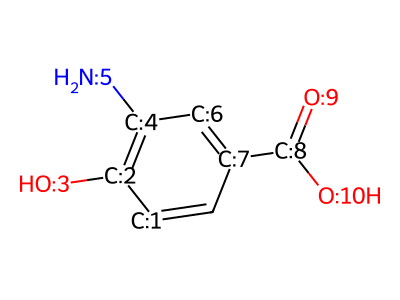

In [4]:
# Visualize the molecule with atom indices for reference
mol_with_idx = Chem.MolFromSmiles("c1cc(O)c(N)cc1C(=O)O")
for atom in mol_with_idx.GetAtoms():
    atom.SetAtomMapNum(atom.GetIdx())

Draw.MolToImage(mol_with_idx, size=(400, 300))

### 1.2 Bond Primitives

Bonds in SMARTS let you specify the *type* of connection between atoms:

| Primitive | Meaning | Example context |
|-----------|---------|-----------------|
| `-` | Single bond | Alkanes, C-O in alcohols |
| `=` | Double bond | Carbonyls, alkenes |
| `#` | Triple bond | Nitriles, alkynes |
| `:` | Aromatic bond | Bonds within benzene, pyridine rings |
| `~` | Any bond | Wildcard — "I don't care about bond order" |
| `@` | Ring bond | Bond that is part of a ring |

**Key insight**: In SMARTS, an implicit (unwritten) bond between atoms means "single or aromatic,"
which differs from SMILES where an implicit bond means "single." This is a common gotcha.

In [ ]:
# --- Bond primitives in action ---
# Cinnamaldehyde: conjugated system with aromatic ring, C=C, and C=O
mol = Chem.MolFromSmiles("O=CC=Cc1ccccc1")  # cinnamaldehyde

bond_patterns = {
    "C=O (carbonyl)":          "[#6]=[#8]",
    "C=C (alkene)":            "[#6]=[#6]",
    "C-C single bond":         "[#6]-[#6]",
    "Any aromatic bond":       "[#6]:[#6]",
    "Any bond to oxygen":      "[#6]~[#8]",
    "C=C in ring (@)":         "[#6]=@[#6]",
    "C=C not in ring (!@)":    "[#6]=!@[#6]",
}

print("Molecule: Cinnamaldehyde (O=CC=Cc1ccccc1)")
print("-" * 55)

for desc, smarts in bond_patterns.items():
    pat = Chem.MolFromSmarts(smarts)
    matches = mol.GetSubstructMatches(pat)
    print(f"{desc:30s} -> {len(matches)} matches: {matches}")

### 1.3 Recursive SMARTS — Matching Within Context

This is where SMARTS gets truly powerful. Recursive SMARTS use the `$()` notation to define an atom
by its *environment*. This is the computational equivalent of saying "find me a carbonyl carbon, but
only if it's connected to an OH" (i.e., a carboxylic acid, not a ketone or aldehyde).

**Syntax**: `[$(<SMARTS>)]` — the atom must match the first atom of the enclosed SMARTS pattern.

| Recursive SMARTS | Meaning |
|-----------------|---------|
| `[$([CX3](=O)[OX2H1])]` | Carboxylic acid carbon (C with =O and -OH) |
| `[$([CX3](=O)[NX3])]` | Amide carbon |
| `[$([NX3;H2;!$(NC=O)])]` | Primary amine nitrogen (but NOT if it's an amide) |

The last example shows the real power: you can use **negation within context** to exclude
specific environments. This is like saying "find me primary amines, but ignore amide N-H bonds"
— exactly the kind of distinction that matters for reactivity predictions.

In [5]:
# --- Recursive SMARTS in action ---
# p-Aminobenzoic acid (PABA) — has both a primary amine AND a carboxylic acid
# Acetaminophen — has an amide N-H (not a free amine)
paba = Chem.MolFromSmiles("NC1=CC=C(C(=O)O)C=C1")            # PABA
acetaminophen = Chem.MolFromSmiles("CC(=O)NC1=CC=C(O)C=C1")   # acetaminophen

# Simple primary amine: matches ANY NH2 connected to carbon
simple_amine = Chem.MolFromSmarts("[NX3H2][#6]")

# Recursive SMARTS: primary amine BUT NOT if the N is part of an amide
selective_amine = Chem.MolFromSmarts("[NX3H2;!$([NX3H2]C(=O))]")

print("Simple amine pattern [NX3H2][#6]:")
print(f"  PABA:          {paba.HasSubstructMatch(simple_amine)}")
print(f"  Acetaminophen: {acetaminophen.HasSubstructMatch(simple_amine)}")

print("\nRecursive SMARTS [NX3H2;!$([NX3H2]C(=O))]:")
print(f"  PABA:          {paba.HasSubstructMatch(selective_amine)}")
print(f"  Acetaminophen: {acetaminophen.HasSubstructMatch(selective_amine)}")
print("\n-> The recursive pattern correctly excludes the amide N-H in acetaminophen!")

Simple amine pattern [NX3H2][#6]:
  PABA:          True
  Acetaminophen: False

Recursive SMARTS [NX3H2;!$([NX3H2]C(=O))]:
  PABA:          True
  Acetaminophen: False

-> The recursive pattern correctly excludes the amide N-H in acetaminophen!


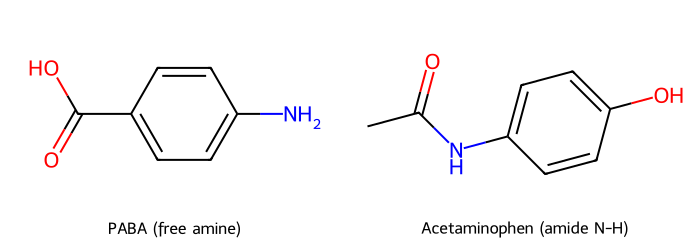

In [6]:
# Visualize both molecules side by side for clarity
img = Draw.MolsToGridImage(
    [paba, acetaminophen],
    molsPerRow=2,
    subImgSize=(350, 250),
    legends=["PABA (free amine)", "Acetaminophen (amide N-H)"],
)
img

---

## 2. Substructure Matching

### Chemistry refresher: Regiochemistry in pattern matching

When you draw a substituted benzene on paper and ask "where is the ester?", there's usually one answer.
But computationally, **a pattern can match in multiple ways** — especially in symmetric molecules.
RDKit gives you three levels of matching:

| Method | Returns | Use case |
|--------|---------|----------|
| `HasSubstructMatch(pattern)` | `bool` | Quick filter: "Does this molecule contain a carboxylic acid?" |
| `GetSubstructMatch(pattern)` | `tuple` of atom indices | First match only — useful when you just need one |
| `GetSubstructMatches(pattern)` | `tuple` of `tuple`s | All matches — critical for counting occurrences |

Think of it like staining a tissue slide: `HasSubstructMatch` tells you if the stain took,
`GetSubstructMatch` shows you the first spot, and `GetSubstructMatches` maps every stained region.

In [8]:
# --- The three levels of matching ---
# Aspirin: contains both an ester and a carboxylic acid
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")

ester = Chem.MolFromSmarts("[CX3](=O)[OX2][#6]")
acid = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")

# Level 1: Boolean — does the substructure exist?
print("=== HasSubstructMatch (boolean) ===")
print(f"Aspirin has ester?          {aspirin.HasSubstructMatch(ester)}")
print(f"Aspirin has carboxylic acid? {aspirin.HasSubstructMatch(acid)}")

# Level 2: First match — tuple of atom indices
print("\n=== GetSubstructMatch (first match) ===")
first_ester = aspirin.GetSubstructMatch(ester)
print(f"First ester match (atom indices): {first_ester}")

# Level 3: All matches — tuple of tuples
print("\n=== GetSubstructMatches (all matches) ===")
all_esters = aspirin.GetSubstructMatches(ester)
print(f"All ester matches: {all_esters}")

all_acids = aspirin.GetSubstructMatches(acid)
print(f"All acid matches:  {all_acids}")

=== HasSubstructMatch (boolean) ===
Aspirin has ester?          True
Aspirin has carboxylic acid? True

=== GetSubstructMatch (first match) ===
First ester match (atom indices): (1, 2, 3, 4)

=== GetSubstructMatches (all matches) ===
All ester matches: ((1, 2, 3, 4),)
All acid matches:  ((10, 11, 12),)


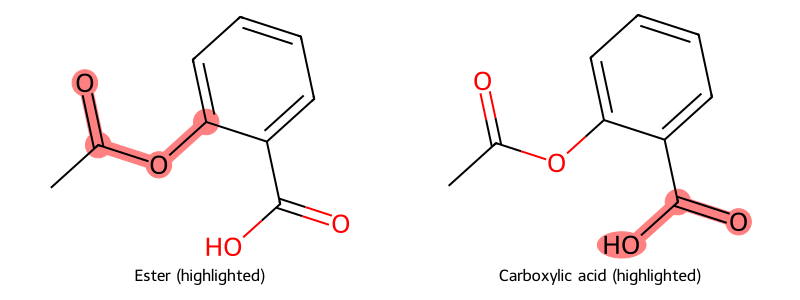

In [9]:
# Visualize aspirin with the ester highlighted
ester_atoms = list(aspirin.GetSubstructMatch(ester))
acid_atoms = list(aspirin.GetSubstructMatch(acid))

img = Draw.MolsToGridImage(
    [aspirin, aspirin],
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=["Ester (highlighted)", "Carboxylic acid (highlighted)"],
    highlightAtomLists=[ester_atoms, acid_atoms],
)
img

### Symmetry and multiple matches

Symmetric molecules are a great way to understand why `GetSubstructMatches` returns *all* possible
mappings. In naphthalene, a benzene ring pattern can map onto the molecule in many equivalent ways
because of the molecular symmetry.

This is analogous to how ortho, meta, and para positions on a monosubstituted benzene are *different*
sites even though the ring looks uniform. The matching engine sees every valid atom-to-atom mapping.

In [11]:
# --- Symmetry: multiple matches in naphthalene ---
naphthalene = Chem.MolFromSmiles("c1ccc2ccccc2c1")
benzene_pattern = Chem.MolFromSmarts("c1ccccc1")

all_matches = naphthalene.GetSubstructMatches(benzene_pattern)
print(f"Benzene ring in naphthalene: {len(all_matches)} match mappings")
for i, match in enumerate(all_matches):
    print(f"  Mapping {i}: atoms {match}")

# Note: many mappings because each ring can be traversed in different directions
# Use uniquify=True (default) to get unique atom sets,
# or uniquify=False to see all permutations
unique_matches = naphthalene.GetSubstructMatches(benzene_pattern, uniquify=True)
print(f"\nWith uniquify=True: {len(unique_matches)} unique matches")
for i, match in enumerate(unique_matches):
    print(f"  Ring {i}: atoms {match}")

Benzene ring in naphthalene: 2 match mappings
  Mapping 0: atoms (0, 1, 2, 3, 8, 9)
  Mapping 1: atoms (3, 4, 5, 6, 7, 8)

With uniquify=True: 2 unique matches
  Ring 0: atoms (0, 1, 2, 3, 8, 9)
  Ring 1: atoms (3, 4, 5, 6, 7, 8)


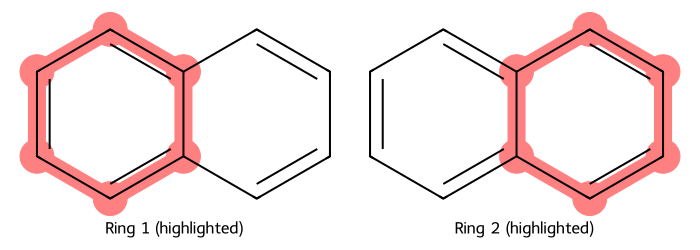

In [14]:
# Visualize both rings in naphthalene
if len(unique_matches) >= 2:
    img = Draw.MolsToGridImage(
        [naphthalene, naphthalene],
        molsPerRow=2,
        subImgSize=(350, 250),
        legends=["Ring 1 (highlighted)", "Ring 2 (highlighted)"],
        highlightAtomLists=[list(unique_matches[0]), list(unique_matches[1])],
    )
img

---

## 3. Practical SMARTS Library — Building a Functional Group Scanner

### Chemistry refresher: Functional groups define reactivity

In organic chemistry, functional groups are the foundation of **retrosynthetic analysis**. When you
look at a target molecule, you mentally decompose it into functional groups and plan disconnections.
A computational functional group scanner automates what an experienced chemist does mentally when
assessing a structure — but it does it consistently across thousands of compounds without fatigue.

This is directly useful for:
- **Synthetic accessibility scoring** — can we actually make this?
- **ADMET prediction** — certain functional groups flag toxicity or metabolic liability
- **Library enumeration** — which building blocks have the right handles?
- **Patent landscaping** — does this compound fall within a Markush claim?

Below we build a reusable scanner with carefully curated SMARTS patterns.

In [16]:
# --- Functional Group SMARTS Library ---
# Each SMARTS is carefully constructed to match the chemist's definition
# of each functional group, avoiding common false positives.

FUNCTIONAL_GROUPS = {
    # Oxygen-containing
    "Alcohol":          "[OX2H1][CX4]",          # -OH on sp3 carbon
    "Phenol":           "[OX2H1]c1ccccc1",        # -OH on aromatic ring
    "Ether":            "[OD2]([#6])[#6]",         # R-O-R (2 carbon neighbors)
    "Aldehyde":         "[CX3H1](=O)[#6]",        # R-CHO
    "Ketone":           "[CX3](=[OX1])([#6])[#6]", # R-CO-R
    "Carboxylic acid":  "[CX3](=O)[OX2H1]",       # R-COOH
    "Ester":            "[CX3](=O)[OX2][#6]",      # R-COO-R
    "Anhydride":        "[CX3](=O)[OX2][CX3](=O)", # R-CO-O-CO-R

    # Nitrogen-containing
    "Primary amine":    "[NX3H2][CX4]",            # R-NH2 on sp3 carbon
    "Secondary amine":  "[NX3H1]([CX4])[CX4]",    # R2-NH
    "Tertiary amine":   "[NX3]([CX4])([CX4])[CX4]", # R3-N
    "Amide":            "[NX3][CX3](=[OX1])",       # R-CONR2
    "Nitro":            "[NX3](=O)=O",              # R-NO2
    "Nitrile":          "[NX1]#[CX2]",              # R-CN
    "Imine":            "[CX3]=[NX2]",              # R2C=NR

    # Sulfur-containing
    "Thiol":            "[SX2H1]",                  # R-SH
    "Sulfonamide":      "[SX4](=[OX1])(=[OX1])([NX3])", # R-SO2-NR2
    "Sulfone":          "[SX4](=[OX1])(=[OX1])([#6])[#6]", # R-SO2-R
    "Sulfoxide":        "[SX3](=[OX1])([#6])[#6]",  # R-SO-R

    # Halogens
    "Alkyl halide":     "[CX4][F,Cl,Br,I]",        # R-X
    "Aryl halide":      "[c][F,Cl,Br,I]",           # Ar-X

    # Unsaturation
    "Alkene":           "[CX3]=[CX3]",              # C=C
    "Alkyne":           "[CX2]#[CX2]",              # C#C
}

print(f"Library contains {len(FUNCTIONAL_GROUPS)} functional group patterns")
print("\nGroups:", ", ".join(FUNCTIONAL_GROUPS.keys()))

Library contains 23 functional group patterns

Groups: Alcohol, Phenol, Ether, Aldehyde, Ketone, Carboxylic acid, Ester, Anhydride, Primary amine, Secondary amine, Tertiary amine, Amide, Nitro, Nitrile, Imine, Thiol, Sulfonamide, Sulfone, Sulfoxide, Alkyl halide, Aryl halide, Alkene, Alkyne


In [17]:
def scan_functional_groups(mol, fg_dict=FUNCTIONAL_GROUPS):
    """
    Scan a molecule for functional groups defined by SMARTS patterns.

    Parameters
    ----------
    mol : rdkit.Chem.Mol
        RDKit molecule object
    fg_dict : dict
        Dictionary mapping group names to SMARTS strings

    Returns
    -------
    dict
        {group_name: count} for each group found (count >= 1)
    """
    results = {}
    for name, smarts in fg_dict.items():
        pattern = Chem.MolFromSmarts(smarts)
        if pattern is None:
            print(f"  WARNING: Invalid SMARTS for {name}: {smarts}")
            continue
        matches = mol.GetSubstructMatches(pattern)
        if matches:
            results[name] = len(matches)
    return results


# Test on a diverse set of well-known drugs
test_mols = {
    "Aspirin":           "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Acetaminophen":     "CC(=O)NC1=CC=C(O)C=C1",
    "Ibuprofen":         "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Lidocaine":         "CCN(CC)CC(=O)NC1=C(C)C=CC=C1C",
    "Sulfamethoxazole":  "CC1=CC(=NO1)NS(=O)(=O)C1=CC=C(N)C=C1",
}

for name, smi in test_mols.items():
    mol = Chem.MolFromSmiles(smi)
    groups = scan_functional_groups(mol)
    print(f"\n{name} ({smi}):")
    for fg, count in groups.items():
        print(f"  {fg}: {count}")


Aspirin (CC(=O)OC1=CC=CC=C1C(=O)O):
  Ether: 1
  Carboxylic acid: 1
  Ester: 1

Acetaminophen (CC(=O)NC1=CC=C(O)C=C1):
  Phenol: 1
  Amide: 1

Ibuprofen (CC(C)CC1=CC=C(C=C1)C(C)C(=O)O):
  Carboxylic acid: 1

Lidocaine (CCN(CC)CC(=O)NC1=C(C)C=CC=C1C):
  Tertiary amine: 1
  Amide: 1

Sulfamethoxazole (CC1=CC(=NO1)NS(=O)(=O)C1=CC=C(N)C=C1):
  Sulfonamide: 1


In [ ]:
# Visualize the test molecules in a grid
mol_objects = []
legends = []
for name, smi in test_mols.items():
    mol = Chem.MolFromSmiles(smi)
    mol_objects.append(mol)
    legends.append(name)

img = Draw.MolsToGridImage(
    mol_objects,
    molsPerRow=3,
    subImgSize=(350, 250),
    legends=legends,
)
img

In [ ]:
# --- Build a summary DataFrame ---
# This is the kind of output you'd use for library profiling

rows = []
for name, smi in test_mols.items():
    mol = Chem.MolFromSmiles(smi)
    groups = scan_functional_groups(mol)
    row = {"Molecule": name}
    row.update(groups)
    rows.append(row)

df = pd.DataFrame(rows).set_index("Molecule").fillna(0).astype(int)

# Only show columns that have at least one non-zero value
df = df.loc[:, (df != 0).any(axis=0)]
df

### Practical note: SMARTS pattern overlap

You may notice that some molecules match patterns you wouldn't expect. For example, the ester
oxygen in aspirin is bonded to two carbons, so it also matches the ether pattern `[OD2]([#6])[#6]`.
This is a well-known issue in functional group classification.

**How to handle it in practice:**
1. **Priority rules** — If ester is detected, suppress ether at the same atoms
2. **Recursive SMARTS** — Use `[OD2;!$([OD2][CX3]=O)]([#6])[#6]` for ether (exclude ester O)
3. **Post-processing** — Filter overlapping groups after scanning

The right approach depends on your application. For ADMET flagging, overcounting is often fine.
For synthetic route planning, you want precise, non-overlapping assignments.

---

## 4. Maximum Common Substructure (MCS)

### Chemistry refresher: Scaffold hopping in medicinal chemistry

In drug discovery, **scaffold hopping** is the strategy of finding molecules that share a common
pharmacophoric core but differ in their peripheral substituents. The Maximum Common Substructure
(MCS) algorithm finds the largest subgraph that is common to two or more molecules.

This is the computational equivalent of overlaying two molecules on a lightbox and tracing what
they have in common. It's directly useful for:
- **SAR (Structure-Activity Relationship) analysis** — what's the shared core across active compounds?
- **R-group decomposition** — split molecules into core + substituents
- **Series identification** — cluster a library by shared scaffolds
- **Patent claim analysis** — determine if a novel compound shares a Markush core

In [21]:
# --- MCS between two NSAIDs ---
# Ibuprofen and naproxen are both propionic acid derivatives
# but with different aromatic scaffolds

ibuprofen = Chem.MolFromSmiles("CC(C)CC1=CC=C(C=C1)C(C)C(=O)O")
naproxen = Chem.MolFromSmiles("COC1=CC2=CC(=CC2=CC1)C(C)C(=O)O")

mcs_result = rdFMCS.FindMCS([ibuprofen, naproxen])

print("MCS between Ibuprofen and Naproxen")
print("=" * 50)
print(f"MCS SMARTS:  {mcs_result.smartsString}")
print(f"Num atoms:   {mcs_result.numAtoms}")
print(f"Num bonds:   {mcs_result.numBonds}")
print(f"\nInterpretation: The shared core is the aryl-propionic acid motif")
print("that defines this entire NSAID class.")

MCS between Ibuprofen and Naproxen
MCS SMARTS:  [#6]:,-[#6]-[#6](-[#6])-[#6](=[#8])-[#8]
Num atoms:   7
Num bonds:   6

Interpretation: The shared core is the aryl-propionic acid motif
that defines this entire NSAID class.


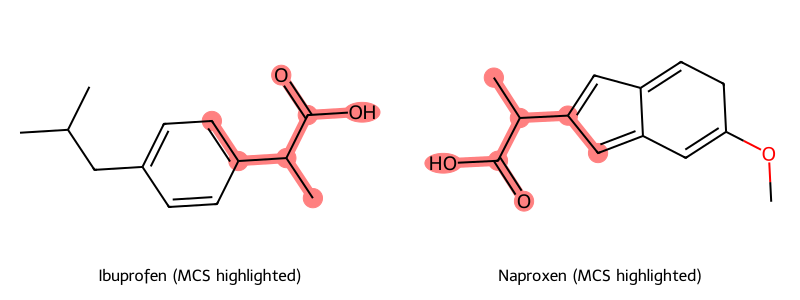

In [22]:
# Visualize the MCS highlighted on both molecules
mcs_mol = Chem.MolFromSmarts(mcs_result.smartsString)

match1 = ibuprofen.GetSubstructMatch(mcs_mol)
match2 = naproxen.GetSubstructMatch(mcs_mol)

img = Draw.MolsToGridImage(
    [ibuprofen, naproxen],
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=["Ibuprofen (MCS highlighted)", "Naproxen (MCS highlighted)"],
    highlightAtomLists=[list(match1), list(match2)],
)
img

### MCS with multiple molecules and tuning parameters

When finding the MCS across more than two molecules, the result gets smaller (the more molecules,
the less they all have in common). RDKit's `FindMCS` supports several parameters to tune the search:

| Parameter | Effect |
|-----------|--------|
| `ringMatchesRingOnly=True` | Ring bonds only match ring bonds (prevents false ring-chain equivalences) |
| `completeRingsOnly=True` | Only include complete rings in the MCS (no partial ring matches) |
| `bondCompare=rdFMCS.BondCompare.CompareOrder` | Match exact bond orders |
| `atomCompare=rdFMCS.AtomCompare.CompareElements` | Match exact elements |
| `timeout=10` | Stop after 10 seconds (MCS is NP-hard — large molecules can be slow) |

In [23]:
# --- MCS across multiple NSAIDs ---
nsaids = {
    "Ibuprofen":   "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Naproxen":    "COC1=CC2=CC(=CC2=CC1)C(C)C(=O)O",
    "Flurbiprofen": "FC1=CC(=C(C=C1)C1=CC=CC=C1)C(C)C(=O)O",
    "Ketoprofen":  "CC(C(=O)O)C1=CC(=CC=C1)C(=O)C1=CC=CC=C1",
}

nsaid_mols = [Chem.MolFromSmiles(smi) for smi in nsaids.values()]

# Default MCS
mcs_default = rdFMCS.FindMCS(nsaid_mols, timeout=10)
print("Default MCS across 4 profen-class NSAIDs:")
print(f"  SMARTS: {mcs_default.smartsString}")
print(f"  Atoms:  {mcs_default.numAtoms}")
print(f"  Bonds:  {mcs_default.numBonds}")

# With ringMatchesRingOnly — more chemically meaningful
mcs_ring = rdFMCS.FindMCS(
    nsaid_mols,
    ringMatchesRingOnly=True,
    completeRingsOnly=True,
    timeout=10,
)
print(f"\nWith ringMatchesRingOnly + completeRingsOnly:")
print(f"  SMARTS: {mcs_ring.smartsString}")
print(f"  Atoms:  {mcs_ring.numAtoms}")
print(f"  Bonds:  {mcs_ring.numBonds}")

Default MCS across 4 profen-class NSAIDs:
  SMARTS: [#6]:,-[#6]-[#6](-[#6])-[#6](=[#8])-[#8]
  Atoms:  7
  Bonds:  6

With ringMatchesRingOnly + completeRingsOnly:
  SMARTS: [#6&R]-&!@[#6&!R](-&!@[#6&!R])-&!@[#6&!R](=&!@[#8&!R])-&!@[#8&!R]
  Atoms:  6
  Bonds:  5


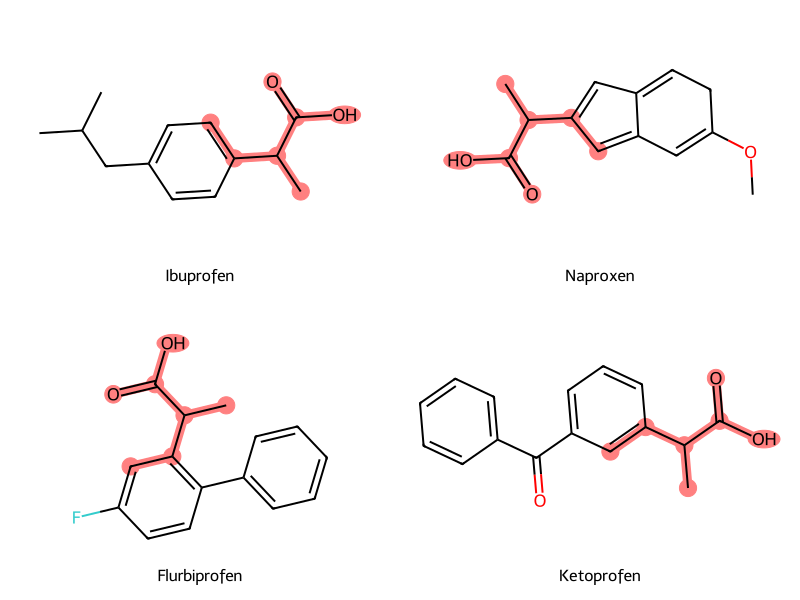

In [24]:
# Visualize all 4 NSAIDs with the default MCS highlighted
mcs_pattern = Chem.MolFromSmarts(mcs_default.smartsString)

highlight_lists = []
for mol in nsaid_mols:
    match = mol.GetSubstructMatch(mcs_pattern)
    highlight_lists.append(list(match))

img = Draw.MolsToGridImage(
    nsaid_mols,
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=list(nsaids.keys()),
    highlightAtomLists=highlight_lists,
)
img

### MCS between structurally diverse molecules

MCS becomes especially interesting when comparing molecules from different chemical series.
The shared substructure (or lack thereof) tells you about structural similarity at a deeper
level than simple fingerprint-based metrics.

MCS between Diazepam and Phenobarbital
MCS SMARTS: [#6]1:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@[#6]:&@1
Num atoms:  6
Num bonds:  6

They share a phenyl ring — the minimal pharmacophoric
element common to both CNS depressant scaffolds.


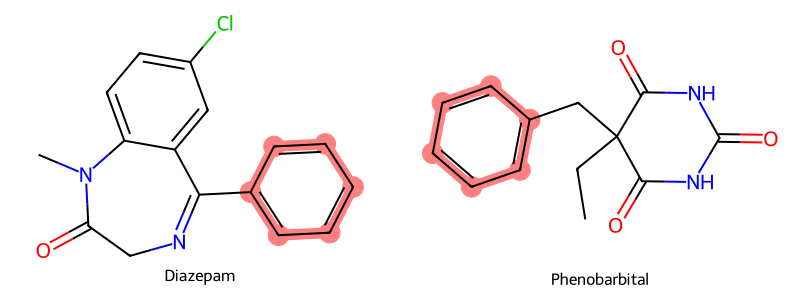

In [25]:
# --- MCS between structurally diverse molecules ---
# Compare a benzodiazepine (diazepam) with a barbiturate (phenobarbital)
# Both are CNS depressants but from different structural classes

diazepam = Chem.MolFromSmiles("CN1C(=O)CN=C(C2=CC=CC=C2)C2=CC(Cl)=CC=C21")
phenobarbital = Chem.MolFromSmiles("O=C1NC(=O)C(CC)(CC2=CC=CC=C2)C(=O)N1")

mcs_diverse = rdFMCS.FindMCS(
    [diazepam, phenobarbital],
    ringMatchesRingOnly=True,
    timeout=10,
)

print("MCS between Diazepam and Phenobarbital")
print("=" * 50)
print(f"MCS SMARTS: {mcs_diverse.smartsString}")
print(f"Num atoms:  {mcs_diverse.numAtoms}")
print(f"Num bonds:  {mcs_diverse.numBonds}")
print(f"\nThey share a phenyl ring — the minimal pharmacophoric")
print("element common to both CNS depressant scaffolds.")

# Visualize
mcs_div_mol = Chem.MolFromSmarts(mcs_diverse.smartsString)
match_d = diazepam.GetSubstructMatch(mcs_div_mol)
match_p = phenobarbital.GetSubstructMatch(mcs_div_mol)

img = Draw.MolsToGridImage(
    [diazepam, phenobarbital],
    molsPerRow=2,
    subImgSize=(400, 300),
    legends=["Diazepam", "Phenobarbital"],
    highlightAtomLists=[list(match_d), list(match_p)],
)
img

---

## 5. Summary

In this notebook we covered the core tools for **substructure searching** in RDKit:

### What we learned

| Topic | Key takeaway |
|-------|-------------|
| **SMARTS language** | Extends SMILES with query features: atomic primitives (`[#6]`, `[R]`, `[D3]`), bond primitives (`=`, `~`, `@`), and recursive SMARTS (`$()`) for context-dependent matching |
| **Substructure matching** | Three levels — `HasSubstructMatch` (boolean), `GetSubstructMatch` (first hit), `GetSubstructMatches` (all hits) |
| **Functional group scanning** | SMARTS patterns can encode a reusable library for automated functional group recognition |
| **MCS** | `rdFMCS.FindMCS` finds the largest shared scaffold; `ringMatchesRingOnly` and `completeRingsOnly` give chemically meaningful results |

### Bridging wet-lab and computational

- SMARTS encodes the same structural intuition you use when reading a molecule on paper
- Substructure matching is the computational equivalent of "spot the functional group"
- MCS automates scaffold comparison that med-chemists do mentally during SAR analysis
- The functional group scanner we built works identically to how you'd annotate a compound table by hand — but scales to millions of molecules

### Up next

In **Notebook 05**, we'll explore **chemical reactions and transformations** — using RDKit's reaction
SMARTS (SMIRKS) to encode synthetic transformations and perform virtual reactions programmatically.
This builds directly on the SMARTS knowledge from this notebook.